In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import cv2 as cv
from IPython.display import Image

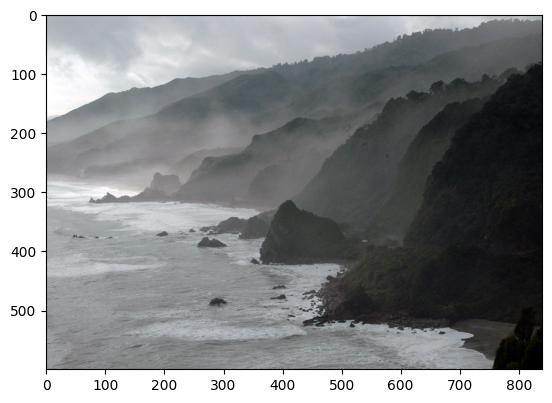

In [ ]:
img=cv.imread("/content/NewZealand.jpg",1)
plt.imshow(img[:,:,::-1])

```
Adition or Brightness of image
```

Text(0.5, 1.0, 'Darker Image')

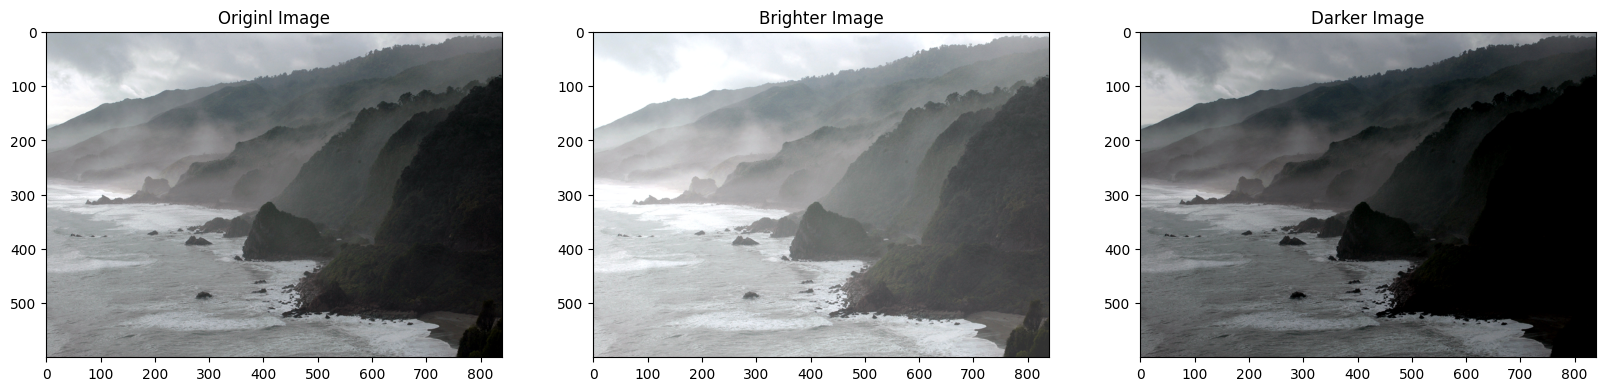

In [ ]:
#Brightness of Image
matrix=np.ones(img.shape,dtype="uint8")*50
img1_rgb_brightness=cv.add(img,matrix)
img1_rgb_darker=cv.subtract(img,matrix)
plt.figure(figsize=(20,5))
plt.subplot(131);plt.imshow(img[:,:,::-1]);plt.title("Originl Image")
plt.subplot(132);plt.imshow(img1_rgb_brightness[:,:,::-1]);plt.title("Brighter Image")
plt.subplot(133);plt.imshow(img1_rgb_darker[:,:,::-1]);plt.title("Darker Image")

```
Multiplication or Contrast of image
```


```
Contrast is the difference between the intensity values of the pixels of an image.

Multiplying the intesity values with constant can make the

difference larger or small

if multiplicating factor is larger than 1 --> larger

if multiplicating factor is less than 1 --> smaller

```


Text(0.5, 1.0, 'Higher Contrast')

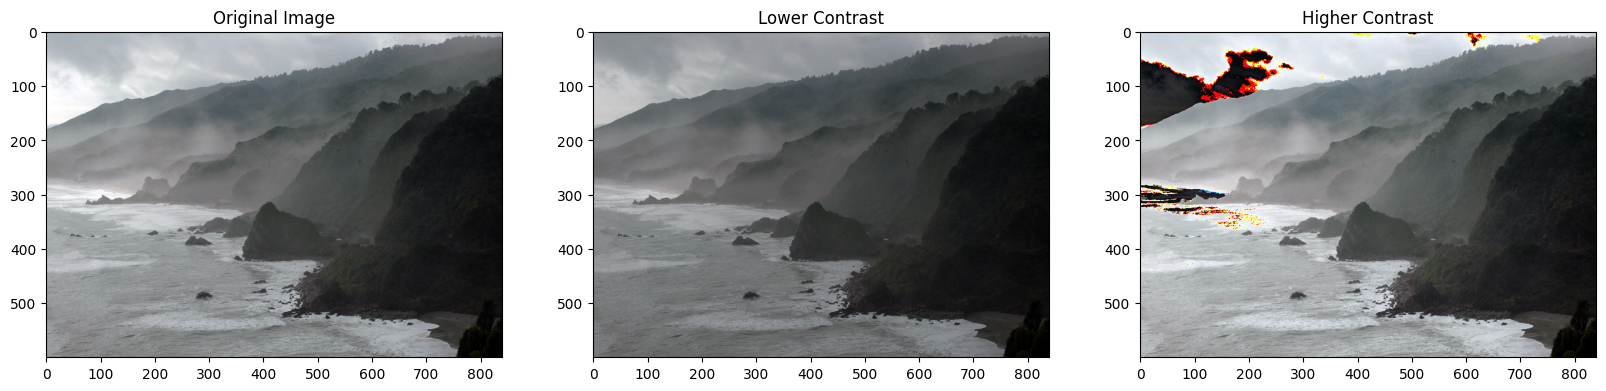

In [ ]:
#Contrast of Image
lower_intesity=np.ones(img.shape)*0.8
higher_intensity=np.ones(img.shape)*1.2
low=np.uint8(cv.multiply(np.float64(img),lower_intesity))
high=np.uint8(cv.multiply(np.float64(img),higher_intensity))
plt.figure(figsize=(20,5))
plt.subplot(131);plt.imshow(img[:,:,::-1]);plt.title("Original Image")
plt.subplot(132);plt.imshow(low[:,:,::-1]);plt.title("Lower Contrast")
plt.subplot(133);plt.imshow(high[:,:,::-1]);plt.title("Higher Contrast")

The patches in the higher contrast image is occuring because the value which are already high are becoming greater than 255. So basically its an overflow issue

Text(0.5, 1.0, 'Higher Contrast')

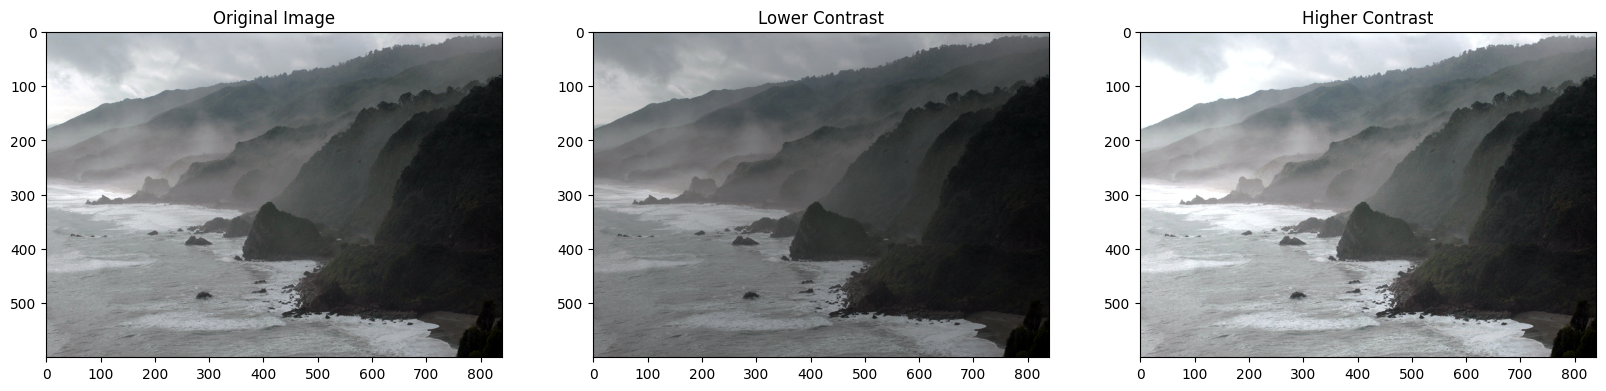

In [ ]:
#Solving the patching problem using clip
low_con=np.ones(img.shape)*0.8
high_con=np.ones(img.shape)*1.2
low=np.uint8(cv.multiply(np.float64(img),low_con))
high=np.uint8(np.clip(cv.multiply(np.float64(img),high_con),0,255))
plt.figure(figsize=(20,5))
plt.subplot(131);plt.imshow(img[:,:,::-1]);plt.title("Original Image")
plt.subplot(132);plt.imshow(low[:,:,::-1]);plt.title("Lower Contrast")
plt.subplot(133);plt.imshow(high[:,:,::-1]);plt.title("Higher Contrast")

Thresholding is a technique of converting a gray scale and  color images

into Binary images. Binary images plays a very important role in image

processing. Binary image help us in image masking. Image masks help us in

processing specific part  of the image keeping the other parts intact.

 can create different thresld images from same original image.

Text(0.5, 1.0, 'Thresholded Image Binary Inv')

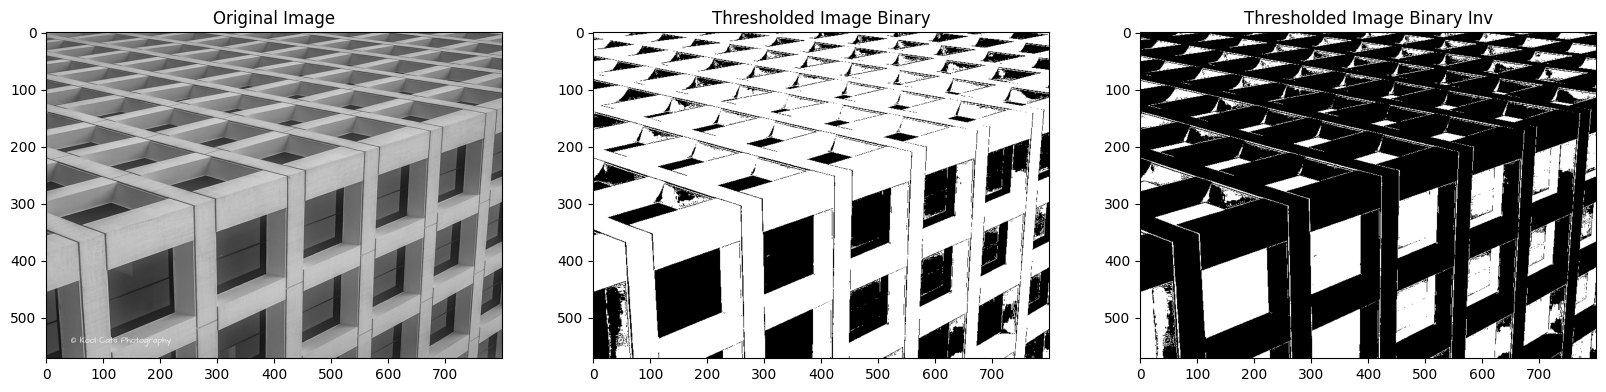

In [ ]:
#Reading the image
windows=cv.imread("/content/building-windows.jpg",0)
#Thresholding the image threshold type Binary
retval,thresold=cv.threshold(windows,100,255,cv.THRESH_BINARY)
#Thresholding the image threshold type is THRESH_BINARY_INV
ret,thre=cv.threshold(windows,100,255,cv.THRESH_BINARY_INV)
plt.figure(figsize=(20,5))
plt.subplot(131);plt.imshow(windows,cmap="gray");plt.title("Original Image")
plt.subplot(132);plt.imshow(thresold,cmap="gray");plt.title("Thresholded Image Binary")
plt.subplot(133);plt.imshow(thre,cmap="gray");plt.title("Thresholded Image Binary Inv")

We have considered threshold value to be 100

When THRESH_BINARY

then where the pixel value is > 100 is set to 255 and the ones less than

100 is set to 0

When THRESH_BINARY_INV

where the pixel value is < 100 is set  to 255 and the one more than 100 is set

to  0


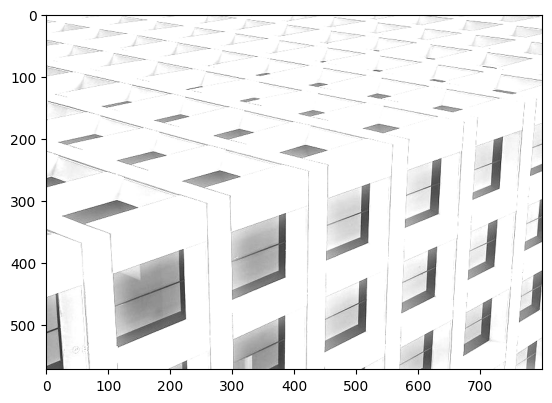

In [ ]:
r,t=cv.threshold(windows, 100, 255, cv.THRESH_TRUNC) ## Where pixel > 100 is set to 100 an the one less than 100 remain as it is
plt.imshow(t,cmap="gray")

Adaptive Thresholding

Text(0.5, 1.0, 'Using Adaptive Thresh Gaussian')

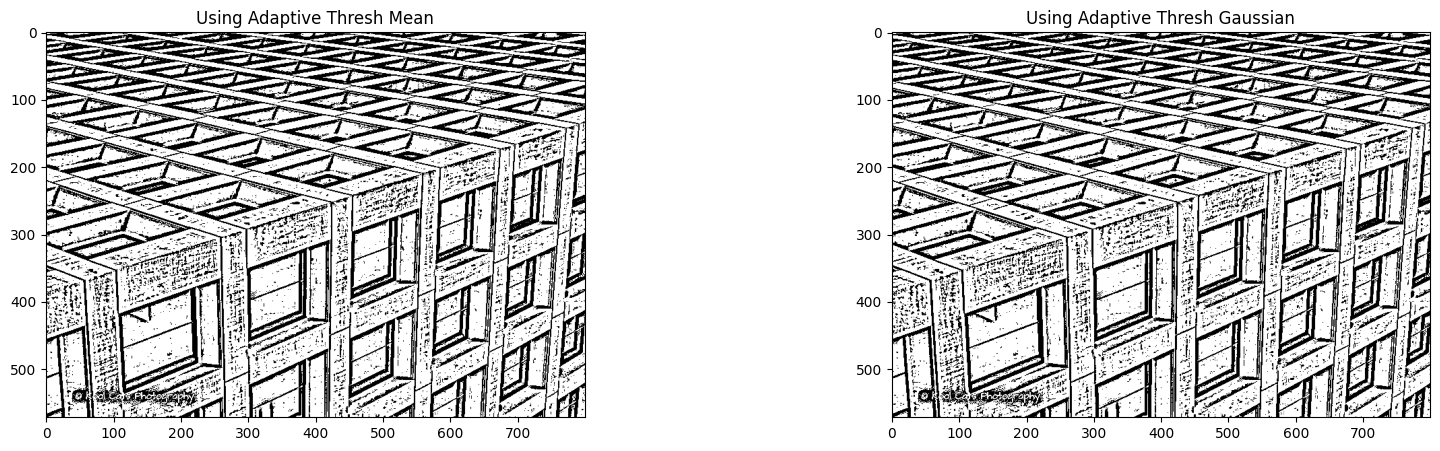

In [ ]:
adap_Mean=cv.adaptiveThreshold(windows,255,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,11,2) #threshold=average of block pixel-c
adap_Gaussian=cv.adaptiveThreshold(windows,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,cv.THRESH_BINARY,11,2)#threshold=weighted average pixels-c (center pixels weighted more)
plt.figure(figsize=(20,5))
plt.subplot(121);plt.imshow(adap_Mean,cmap="gray");plt.title("Using Adaptive Thresh Mean")
plt.subplot(122);plt.imshow(adap_Mean,cmap="gray");plt.title("Using Adaptive Thresh Gaussian")

Text(0.5, 1.0, 'Rectangle')

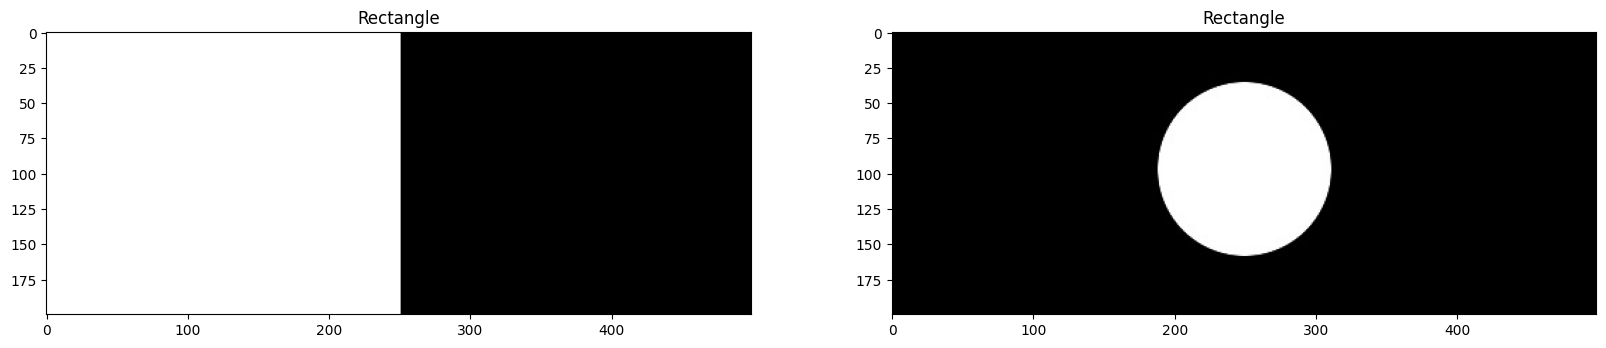

In [ ]:
rect=cv.imread("/content/rectangle.jpg",0)
circle=cv.imread("/content/circle.jpg",0)
plt.figure(figsize=(20,5))

plt.subplot(121);plt.imshow(rect,cmap="gray");plt.title("Rectangle")
plt.subplot(122);plt.imshow(circle,cmap="gray");plt.title("Rectangle")

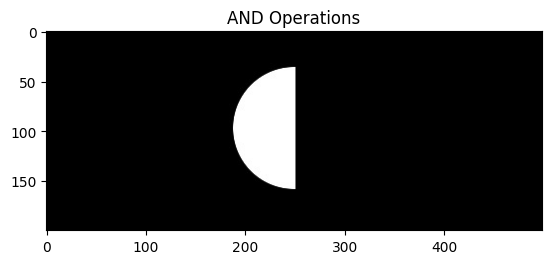

In [ ]:
#Bitwise AND operator
result_bitwise_and=cv.bitwise_and(rect,circle,mask=None)
plt.title("AND Operations")
plt.imshow(result_bitwise_and,cmap="gray")

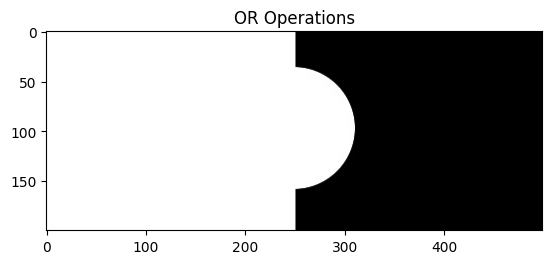

In [ ]:
#Bitwise OR operator
result_bitwise_or=cv.bitwise_or(rect,circle,mask=None)
plt.title("OR Operations")
plt.imshow(result_bitwise_or,cmap="gray")

Text(0.5, 1.0, 'Circle Extraction')

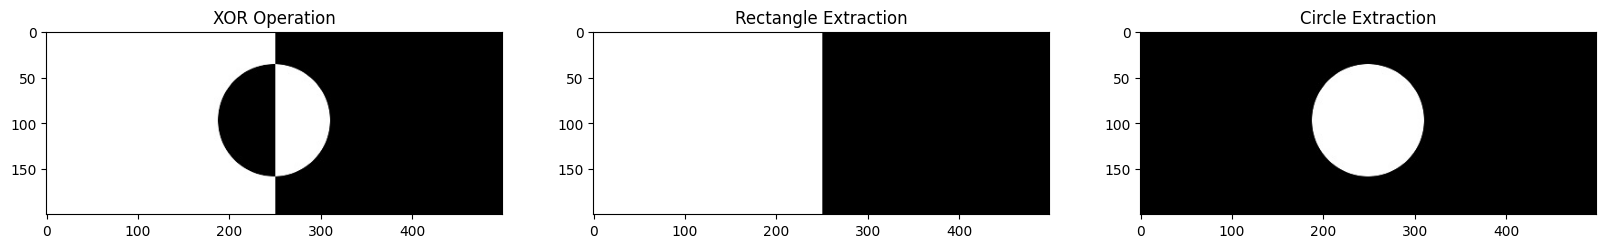

In [ ]:
#Bitwise XOR operator
result_bitwise_xor=cv.bitwise_xor(rect,circle,mask=None)
result_rectangle_extract=cv.bitwise_xor(result_bitwise_xor,circle,mask=None)
result_circle_extract=cv.bitwise_xor(result_bitwise_xor,rect,mask=None)
plt.figure(figsize=(20,5))
plt.subplot(131);plt.imshow(result_bitwise_xor,cmap="gray");plt.title("XOR Operation")
plt.subplot(132);plt.imshow(result_rectangle_extract,cmap="gray");plt.title("Rectangle Extraction")
plt.subplot(133);plt.imshow(result_circle_extract,cmap="gray");plt.title("Circle Extraction")